# 16단계(시각화): 배제율 편향 분석 결과 그래프

15단계에서 만든 배제율 편향 분석 결과를 그래프로 그린다.

**입력**
- `exclusion_bias_by_industry.csv` (업종대분류별 배제율)
- `exclusion_bias_by_industry_detail.csv` (업종별 신뢰가능여부 구성비 교차표)

**출력**
- `exclusion_bias_by_industry_bar.png` (업종대분류별 배제율 막대그래프)
- `exclusion_bias_cross_heatmap.png` (배제 사유 x 업종 교차표 히트맵)

In [1]:
import os
import sys
from importlib import import_module

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

sys.path.append(os.path.abspath("."))
config = import_module("00_config")
utils = import_module("utils")

%matplotlib inline

In [2]:
# 한글 폰트 설정 (Windows 기본 맑은 고딕)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 색상 (dataviz 팔레트 기준: sequential blue)
COLOR_BAR = "#2a78d6"      # 카테고리 슬롯1 / sequential 450
COLOR_AVG_LINE = "#e34948"  # 카테고리 슬롯8 (평균선, 데이터 계열과 구분되는 참조선)
COLOR_TEXT_PRIMARY = "#0b0b0b"
COLOR_TEXT_SECONDARY = "#52514e"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_SURFACE = "#fcfcfb"

BLUE_SEQUENTIAL = [
    "#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95", "#0d366b",
]

In [3]:
def draw_bar_chart(by_major: pd.DataFrame, overall_rate: float, out_file: str):
    plot_df = by_major.sort_values("배제율", ascending=True)

    fig, ax = plt.subplots(figsize=(9, 6), facecolor=COLOR_SURFACE)
    ax.set_facecolor(COLOR_SURFACE)

    y_pos = range(len(plot_df))
    ax.barh(y_pos, plot_df["배제율"], color=COLOR_BAR, height=0.6, zorder=3)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(plot_df.index, color=COLOR_TEXT_PRIMARY, fontsize=10)

    # 값 라벨 (막대 끝)
    for i, v in enumerate(plot_df["배제율"]):
        ax.text(v + 0.8, i, f"{v:.1f}%", va="center", ha="left",
                 color=COLOR_TEXT_SECONDARY, fontsize=9)

    # 전체 평균선
    ax.axvline(overall_rate, color=COLOR_AVG_LINE, linestyle="--", linewidth=1.5, zorder=2)
    ax.text(overall_rate, len(plot_df) - 0.3, f" 전체 평균 {overall_rate:.2f}%",
             color=COLOR_AVG_LINE, fontsize=9, va="bottom", ha="left")

    ax.set_xlabel("배제율 (%)", color=COLOR_TEXT_SECONDARY, fontsize=10)
    ax.set_xlim(0, max(plot_df["배제율"].max(), overall_rate) + 8)
    ax.set_title("업종대분류별 배제율", color=COLOR_TEXT_PRIMARY, fontsize=13, pad=14, loc="left")

    ax.grid(axis="x", color=COLOR_GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(COLOR_MUTED)
    ax.tick_params(axis="x", colors=COLOR_MUTED)
    ax.tick_params(axis="y", length=0)

    fig.tight_layout()
    fig.savefig(out_file, dpi=150, facecolor=COLOR_SURFACE)
    return fig

In [4]:
def draw_heatmap(cross: pd.DataFrame, row_order, out_file: str):
    col_order = [c for c in
                 ["검증완료", "검증불가_층정보없음", "검증불가_동시과다", "검증불가", "검증불가_1층쏠림"]
                 if c in cross.columns]
    cross = cross.reindex(row_order)[col_order]

    cmap = LinearSegmentedColormap.from_list("seq_blue", BLUE_SEQUENTIAL)

    fig, ax = plt.subplots(figsize=(9, 6.5), facecolor=COLOR_SURFACE)
    sns.heatmap(
        cross, cmap=cmap, vmin=0, vmax=100, annot=False,
        linewidths=2, linecolor=COLOR_SURFACE,
        cbar_kws={"label": "비중 (%, 행 기준)"}, ax=ax,
    )

    # 셀 값 대비 색으로 직접 라벨 표시 (밝은 셀=어두운 글자, 어두운 셀=흰 글자)
    for i in range(cross.shape[0]):
        for j in range(cross.shape[1]):
            val = cross.iloc[i, j]
            text_color = "#ffffff" if val >= 50 else COLOR_TEXT_PRIMARY
            ax.text(j + 0.5, i + 0.5, f"{val:.1f}", ha="center", va="center",
                     color=text_color, fontsize=9)

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("업종별 신뢰가능여부 구성비 (%, 행 기준)", color=COLOR_TEXT_PRIMARY,
                 fontsize=13, pad=14, loc="left")
    ax.tick_params(axis="x", colors=COLOR_MUTED, rotation=20)
    ax.tick_params(axis="y", colors=COLOR_MUTED, rotation=0)
    plt.setp(ax.get_xticklabels(), ha="right")

    fig.tight_layout()
    fig.savefig(out_file, dpi=150, facecolor=COLOR_SURFACE)
    return fig

In [5]:
t0 = utils.start_timer()

utils.log("업종대분류별 배제율 CSV 로딩...")
by_major = pd.read_csv(config.out_path("exclusion_bias_by_industry.csv"), index_col=0)
overall_rate = by_major["배제건수"].sum() / by_major["전체건수"].sum() * 100
utils.log(f"로딩 완료 (전체 평균 배제율 {overall_rate:.2f}%)", t0)

utils.log("배제 사유 x 업종 교차표 CSV 로딩...")
cross = pd.read_csv(config.out_path("exclusion_bias_by_industry_detail.csv"), index_col=0)
utils.log("로딩 완료", t0)

by_major

[시작] 업종대분류별 배제율 CSV 로딩...
  [0.0초 경과] 로딩 완료 (전체 평균 배제율 44.62%)
[시작] 배제 사유 x 업종 교차표 CSV 로딩...
  [0.0초 경과] 로딩 완료


,전체건수,배제건수,배제율
상권업종대분류명,,,
숙박,283459,180765,63.77
소매,4315791,2366588,54.84
시설관리·임대,804294,421432,52.40
과학·기술,2923914,1417346,48.47
부동산,984384,456518,46.38
수리·개인,1857183,842517,45.37
음식,5291382,1927795,36.43
교육,1256797,454589,36.17
보건의료,581708,209439,36.00


막대그래프 저장 완료: C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest\store_name_1525\code\exclusion_bias_by_industry_bar.png


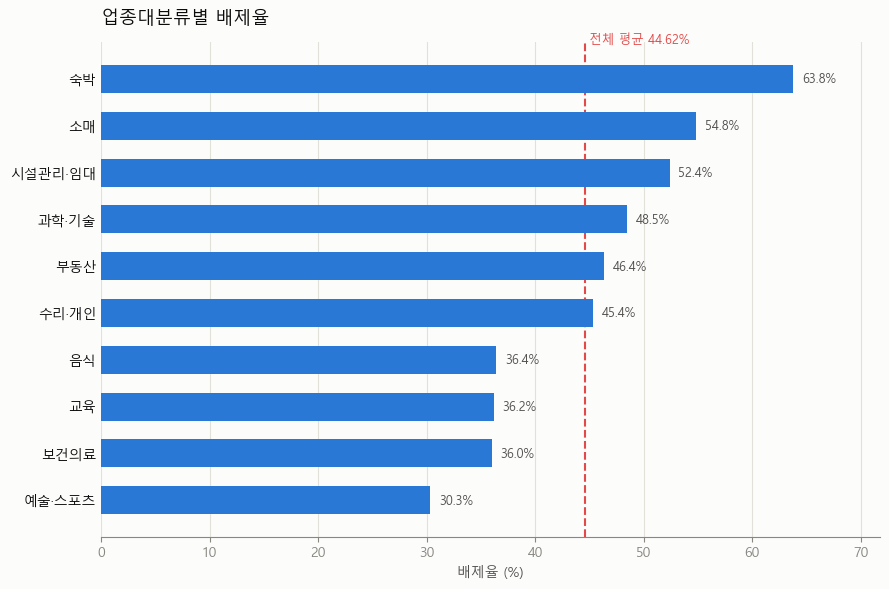

In [6]:
bar_out = config.out_path("exclusion_bias_by_industry_bar.png")
fig_bar = draw_bar_chart(by_major, overall_rate, bar_out)
print(f"막대그래프 저장 완료: {bar_out}")

히트맵 저장 완료: C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest\store_name_1525\code\exclusion_bias_cross_heatmap.png


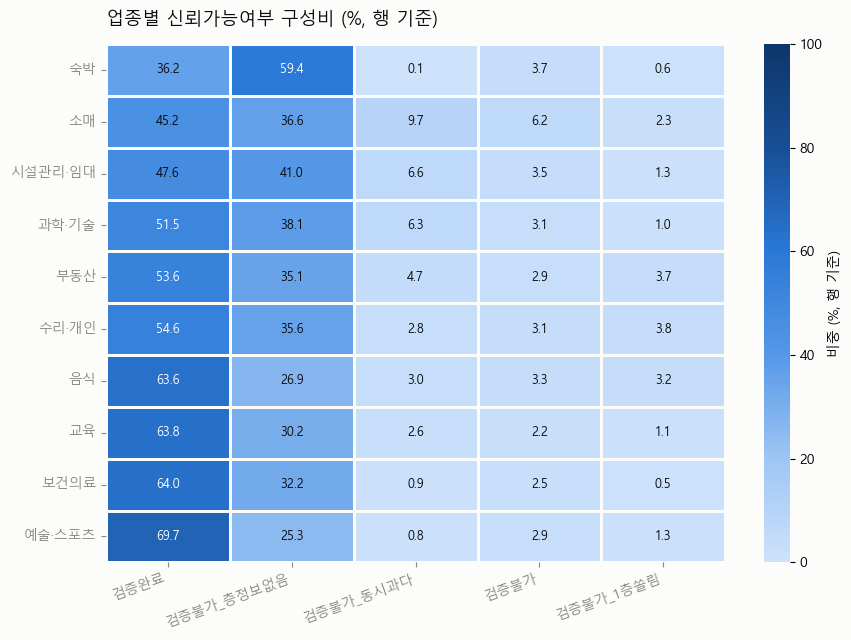

In [7]:
heatmap_out = config.out_path("exclusion_bias_cross_heatmap.png")
fig_heatmap = draw_heatmap(cross, by_major.sort_values("배제율", ascending=False).index, heatmap_out)
print(f"히트맵 저장 완료: {heatmap_out}")